#### Example using DEMReg and SDO/AIA data
Here using a single pixel of SDO/AIA data taken from the event featured in [Hannah & Kontar 2013 A&A](https://doi.org/10.1051/0004-6361/201219727). 

* 26-Oct-2020 IGH
* 04-Nov-2020 - Updated to use v10 aia deg_cor
* 03-Feb-2021 - Updated using new dn2dem_pos_selfnorm function
* 16-Feb-2021 - Updated error calc info
* 16-Jun-2021 - Updated to work with fixed dn2dem_pos, which can do selfnorm, gloci or user wght
* 16-Jun-2021 - Changed dn2dem_pos to now interp tresp in log-space
* 02-Nov-2021 - Checked error from aiapy.calibrate.estimate_error => so now needs aiapy >0.6
* 09-Nov-2021 - Reordered pixel selection to avoid confusion and added vso example
* 23-Nov-2021 - Added in commented out code to save out prepd submaps (to speed code up)
* 23-Nov-2021 - See example_aia_getprep.ipynb to efficiently prep many AIA fits
* 26-Apr-2022 - Checked worked with updated code
* 02-May-2022 - Tweaked import setup and examples
* 23-Oct-2025 - Updated to work with more recent aiapy ver (pointing, deg, errors)

In [1]:
# Import some of the stuff we will need
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
import scipy.io as io
import glob

# DEM inversion (Wilson demregpy)
from demregpy.dn2dem import dn2dem


import astropy.time as atime
from astropy.coordinates import SkyCoord
from astropy import units as u
import sunpy.map

from aiapy.calibrate import degradation
from aiapy.calibrate import register, update_pointing
from aiapy.calibrate.utils import get_pointing_table, get_correction_table, get_error_table

import warnings
warnings.simplefilter('ignore')
matplotlib.rcParams['font.size'] = 16

fdir='/disk/plasma/xw2/sunpy/data/' 

In [28]:
# Can either get the example data via fido/vso or adapt the example to your own AIA data set
from sunpy.net import Fido, attrs as a

# Only want the 6 coronal channels - this might also download 304A
wvsrch=a.Wavelength(94*u.angstrom, 335*u.angstrom)

result = Fido.search(a.Time('2010-11-03T12:15:09', '2010-11-03T12:15:19'), a.Instrument("aia"), wvsrch)
files = Fido.fetch(result,path=fdir)

Files Downloaded:   0%|          | 0/6 [00:00<?, ?file/s]

2026-03-03 16:07:47 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=131_1067861745-1067861745 failed to download with exception

2026-03-03 16:07:47 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=171_1067861747-1067861747 failed to download with exception

2026-03-03 16:07:47 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=211_1067861748-1067861748 failed to download with exception

2026-03-03 16:07:47 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=94_1067861750-1067861750 failed to download with exception

2026-03-03 16:07:47 - parfive - INFO: https://sdo7.nascom.nasa.gov/cgi-bin/drms_export.cgi?series=aia__lev1;compress=rice;record=335_1067861751-1067861751 failed to download with exception



5/0 files failed to download. Please check `.errors` for details


In [2]:
# # Get your AIA data from somewhere like vso or through sunpy and fido (see previous cell)
# # Now load in the fits files
ff=sorted(glob.glob(fdir+'aia*lev1*2010_11_03*.fits'))
print(ff)

# # This data is from the event in Hannah & Kontar 2013 A&A 
# #  https://doi.org/10.1051/0004-6361/201219727

['/disk/plasma/xw2/sunpy/data/aia.lev1.131A_2010_11_03T12_15_09.62Z.image_lev1.fits', '/disk/plasma/xw2/sunpy/data/aia.lev1.171A_2010_11_03T12_15_12.34Z.image_lev1.fits', '/disk/plasma/xw2/sunpy/data/aia.lev1.193A_2010_11_03T12_15_19.84Z.image_lev1.fits', '/disk/plasma/xw2/sunpy/data/aia.lev1.211A_2010_11_03T12_15_12.62Z.image_lev1.fits', '/disk/plasma/xw2/sunpy/data/aia.lev1.335A_2010_11_03T12_15_15.62Z.image_lev1.fits', '/disk/plasma/xw2/sunpy/data/aia.lev1.94A_2010_11_03T12_15_14.12Z.image_lev1.fits']


In [2]:
import os
from datetime import datetime
from astropy import time
from functools import reduce
time_test = time.Time('2022-02-28T22:30:16', scale='utc')
wavenum = ['94', '131', '171', '193', '211', '335']

minute_str = time_test.iso[:16].replace(':', '').replace(' ', 'T')
target_dt = datetime.strptime(time_test.iso[:19], '%Y-%m-%d %H:%M:%S')

local_files = {}
missing_wl = []

for wl in wavenum:
    pattern = os.path.join(fdir, f"aia.lev1_euv_12s.{minute_str}*.{wl}.image_lev1.fits")
    matches = sorted(glob.glob(pattern))
    if matches:
        if len(matches) == 1:
            local_files[wl] = matches[0]
        else:
            def _parse_time(f):
                ts = os.path.basename(f).split('.')[2]
                return datetime.strptime(ts, '%Y-%m-%dT%H%M%SZ')
            matches.sort(key=lambda f: abs((_parse_time(f) - target_dt).total_seconds()))
            local_files[wl] = matches[0]
    else:
        missing_wl.append(wl)

if missing_wl:
    print(f"Missing wavelengths locally: {missing_wl}, will download from JSOC...")
    primekeys = [a.jsoc.PrimeKey('WAVELNTH', wl) for wl in missing_wl]
    q = Fido.search(
        a.Time(time_test, time_test + time.TimeDelta(1, format='sec')),
        a.jsoc.Series('aia.lev1_euv_12s'),
        reduce(lambda x, y: x | y, primekeys),
        a.jsoc.Segment('image'),
        a.jsoc.Notify('xiangyu.wu.23@ucl.ac.uk'),
    )
    fetched = Fido.fetch(q, path=fdir + '{file}')
    for f in fetched:
        for wl in missing_wl:
            if f'.{wl}.image_lev1' in str(f):
                local_files[wl] = str(f)
                break
else:
    print(f"All {len(local_files)} AIA files found locally, skipping JSOC export!")

assert len(local_files) == len(wavenum), f"Missing: {set(wavenum) - set(local_files.keys())}"
print("Local files:")
for wl in wavenum:
    print(f"  {wl}A: {os.path.basename(local_files[wl])}")

All 6 AIA files found locally, skipping JSOC export!
Local files:
  94A: aia.lev1_euv_12s.2022-02-28T223013Z.94.image_lev1.fits
  131A: aia.lev1_euv_12s.2022-02-28T223020Z.131.image_lev1.fits
  171A: aia.lev1_euv_12s.2022-02-28T223022Z.171.image_lev1.fits
  193A: aia.lev1_euv_12s.2022-02-28T223018Z.193.image_lev1.fits
  211A: aia.lev1_euv_12s.2022-02-28T223011Z.211.image_lev1.fits
  335A: aia.lev1_euv_12s.2022-02-28T223014Z.335.image_lev1.fits


In [3]:
# Load in the data, will worry about the order later
ff = [local_files[i] for i in wavenum]
amaps=sunpy.map.Map(ff)

In [4]:
# Get the wavelengths of the maps and get index of sort for this list of maps 
wvn0 = [m.meta['wavelnth'] for m in amaps]
print(wvn0)
srt_id = sorted(range(len(wvn0)), key=wvn0.__getitem__)
print(srt_id)

# And now can reorder them
# OK to do it without creating new list as finding order and reordering in same cell
amaps = [amaps[i] for i in srt_id]
print([m.meta['wavelnth'] for m in amaps])

[94, 131, 171, 193, 211, 335]
[0, 1, 2, 3, 4, 5]
[94, 131, 171, 193, 211, 335]


In [5]:
# aiaprep the images, may take a while to run
# depending on what you are doing could skip this step

pointing_table = get_pointing_table("JSOC", time_range=(amaps[0].date - 12 * u.h, amaps[0].date + 12 * u.h))

aprep=[]
for m in amaps:
    m_temp = update_pointing(m, pointing_table=pointing_table)
    aprep.append(register(m_temp))
print([m.meta['wavelnth'] for m in aprep])

[94, 131, 171, 193, 211, 335]


In [6]:
# As the above steps are the slowest it might be useful to save up the prepd maps, 
# so only need to run once, and them can load them in for the DEM analysis
# 
# Also we don't need the full map so can just save out the bits we need
# blo=[-1150*u.arcsec,-500*u.arcsec]
# tro=[-850*u.arcsec,-200*u.arcsec]

# our region
blo=[-500*u.arcsec,-200*u.arcsec]
tro=[100*u.arcsec,400*u.arcsec]

suba_maps=[]
for a in aprep:
    bottom_left = SkyCoord(blo[0],blo[1], frame=a.coordinate_frame)
    top_right = SkyCoord(tro[0],tro[1], frame=a.coordinate_frame)
    suba_maps.append(a.submap(bottom_left=bottom_left, top_right=top_right))
    
# Now save out the maps - seems that have to be to individual files
# And quickest way to do this is to convert our list to a sunpy sequence first 
# (better way to do this? - mapsequence by default saves sorted by data, which we don't want)
seq=sunpy.map.Map(suba_maps[0],suba_maps[1],suba_maps[2],\
                   suba_maps[3],suba_maps[4],suba_maps[5],sequence=True,sortby=None) 
# seq.save(fdir+'aia_smd_{index:03}.fits',overwrite='True')

In [7]:
# If you have run the above cell once then can just load the submaps back in 
# and don't have to get and prep the data
ffin=sorted(glob.glob(fdir+'aia_smd_*.fits'))
# print(ffin)
aprep=sunpy.map.Map(ffin)
# Print out the order just to check they are stil sorted correctly
print([m.meta['wavelnth'] for m in aprep])

[94, 131, 171, 193, 211, 335]


In [7]:
# Get the durations for the DN/px/s normalisation and
# wavenlength to check the order - should already be sorted above
wvn = [m.meta['wavelnth'] for m in aprep]
worder=np.argsort(wvn)

durs = [m.meta['exptime'] for m in aprep]

# Convert to numpy arrays as make things easier later
durs=np.array(durs)
wvn=np.array(wvn)
print(durs)
print(wvn)

[2.90083  2.901311 1.999554 1.999609 2.901195 2.900793]
[ 94 131 171 193 211 335]


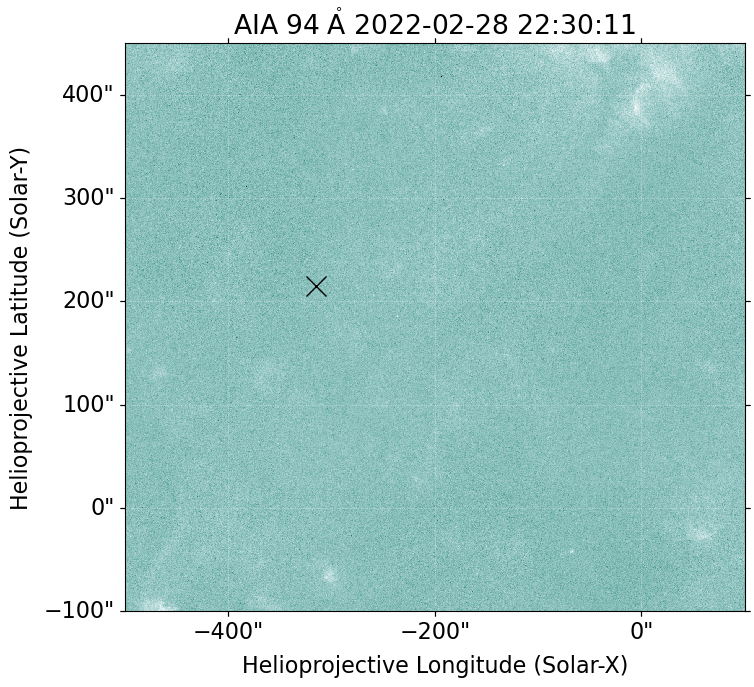

[  0.44967574   2.9741597  157.50475    149.49747     37.454624
   1.295093  ]
Figure saved to: ../results/DEM/one_pixel/dem_feature_1pixel_selection.png


In [8]:
# Plot where the feature is so can pick an interesting location to calc the DEM
bottom_left = SkyCoord(-500*u.arcsec,-100*u.arcsec, frame=aprep[0].coordinate_frame)
top_right = SkyCoord(100*u.arcsec,450*u.arcsec, frame=aprep[0].coordinate_frame)
mm = aprep[0].submap(bottom_left=bottom_left, top_right=top_right)
fig = plt.figure(figsize=(8,8))
ax = plt.subplot(projection=mm)
mm.plot()

# I pick this bright lower coronal position, of hot occulted loop top
# Which is roughly pixel 6 in fig 2 from https://doi.org/10.1051/0004-6361/201219727
px=-315*u.arcsec #-915*u.arcsec
py=215*u.arcsec #-341*u.arcsec

ax.plot_coord(SkyCoord(px,py, frame=mm.coordinate_frame), 'kx', fillstyle='none', markersize=15)
plt.show()

# 1 pixel
# Now use Sunpy to help work out pixel location in terms of data array indices from sun positions
# Loop over each map to extra the DN value out at the chosen pixel location
data=[]
for m in aprep:
    px_loc=m.world_to_pixel(SkyCoord(px,py, frame=m.coordinate_frame))
#   print(px_loc)
#   Remember python array is first dimension row (y), second dimension x (column) - opposite of idl
    data.append(m.data[int(px_loc[1].value),int(px_loc[0].value)])
data=np.array(data)
# Only doing 1 pixel so immediately in units of DN/px
print(data)

import os
# Make sure the output directory exists
save_dir = '../results/DEM/one_pixel/'
os.makedirs(save_dir, exist_ok=True)

# Save the figure generated above (the last active figure to '../results/DEM/')
save_path = os.path.join(save_dir, 'dem_feature_1pixel_selection.png')
# fig.savefig(save_path, bbox_inches='tight')
print(f"Figure saved to: {save_path}")

# If know the array location already can just specify that, i.e. m.data[100,150]
# Or if you want to average over a region, do a submap of the region and average over submap.data

ROI size: 5x5
ROI-averaged DN (per px), channel order follows aprep:
[ 418.9534  2493.186   2312.2537  5999.764   3073.185    271.24094]
Ratio (ROI / single-pixel):
[1. 1. 1. 1. 1. 1.]


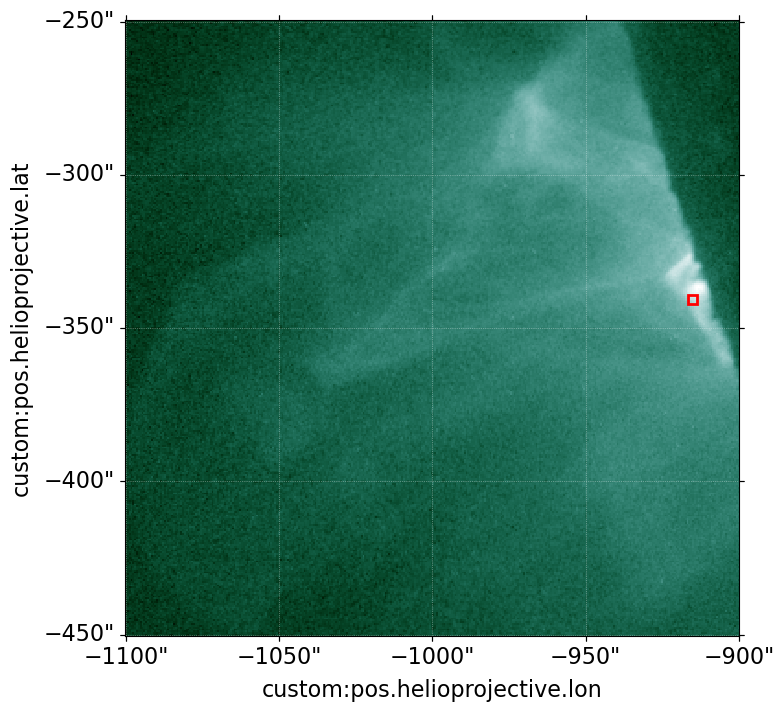

In [26]:
# ===== New cell: ROI average + ROI box overlay (no change to original cell) =====
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from matplotlib.patches import Polygon

# --- user setting ---
half = 2  # 3x3 -> 1; 5x5 -> 2

# --- safety checks ---
required = ["mm", "fig", "ax", "aprep", "px", "py"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"Missing variables {missing}. Run the original pixel-selection/plot cell first.")

# =========================================================
# Part A: draw ROI box on the existing mm plot (WCS-aware)
# =========================================================
c0 = SkyCoord(px, py, frame=mm.coordinate_frame)
p0 = mm.world_to_pixel(c0)
x0 = int(round(p0.x.value))
y0 = int(round(p0.y.value))

# pixel bounds for ROI (use pixel edges for a clean rectangle)
x1, x2 = x0 - half, x0 + half + 1
y1, y2 = y0 - half, y0 + half + 1

corners_pix = [(x1, y1), (x2, y1), (x2, y2), (x1, y2)]
corners_world = [mm.pixel_to_world(x*u.pixel, y*u.pixel) for x, y in corners_pix]
verts_deg = [(c.Tx.to_value(u.deg), c.Ty.to_value(u.deg)) for c in corners_world]


fig2, ax2 = plt.subplots(figsize=(8,8), subplot_kw={'projection': mm})
mm.plot(axes=ax2, annotate=False, title=False)  # 绘制底图

# 绘制 ROI 框
roi_patch = Polygon(
    verts_deg, closed=True, fill=False, linewidth=2, edgecolor='red',
    transform=ax2.get_transform("world")
)
ax2.add_patch(roi_patch)

ax2.text(px.to_value(u.arcsec) + 5,
         py.to_value(u.arcsec) + 5,
         f"{2*half+1}×{2*half+1} ROI",
         transform=ax2.get_transform("world"),
         color="k")

# roi_patch = Polygon(
#     verts_deg, closed=True, fill=False, linewidth=2,
#     transform=ax.get_transform("world")
# )
# ax.add_patch(roi_patch)

# ax.text(px.to_value(u.arcsec) + 5,
#         py.to_value(u.arcsec) + 5,
#         f"{2*half+1}×{2*half+1} ROI",
#         transform=ax.get_transform("world"),
#         color="k")
save_dir = '../results/DEM/roi/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'dem_feature_roi_selection.png')
fig2.savefig(save_path, bbox_inches='tight')

# =========================================================
# Part B: ROI-average DN/px for each channel map in aprep
# =========================================================
data_roi = []
pix_info = []

for m in aprep:
    p = m.world_to_pixel(SkyCoord(px, py, frame=m.coordinate_frame))
    x = int(round(p.x.value))
    y = int(round(p.y.value))

    ny, nx = m.data.shape
    xx1 = max(0, x - half); xx2 = min(nx, x + half + 1)
    yy1 = max(0, y - half); yy2 = min(ny, y + half + 1)

    roi = m.data[yy1:yy2, xx1:xx2]
    data_roi.append(np.nanmean(roi))
    pix_info.append((m.wavelength, x, y, (xx1, xx2, yy1, yy2)))

data_roi = np.array(data_roi)

print(f"ROI size: {(2*half+1)}x{(2*half+1)}")
print("ROI-averaged DN (per px), channel order follows aprep:")
print(data_roi)

# If you also ran the original single-pixel extraction, compare:
if "data" in globals():
    try:
        data_single = np.array(data)
        if data_single.shape == data_roi.shape:
            print("Ratio (ROI / single-pixel):")
            print(data_roi / data_single)
    except Exception:
        pass

# Use ROI-averaged data downstream
data = data_roi.copy()

# Optional: show the updated figure output in the notebook
# fig

In [9]:
# Just check things are sorted in the correct order of [94,131,171,193,211,335]
worder=np.argsort(wvn)
print(worder)
# As sorted after loading the maps in don't need the following lines now
# durs=durs[worder]
# data=data[worder]

[0 1 2 3 4 5]


In [10]:
# Let's get the degradation correction factors
channels = [94,131,171,193,211,335] * u.angstrom
time= time.Time('2022-02-28T22:30:16', scale='utc') #atime.Time('2010-11-03T12:15:00', scale='utc') 
# print(channels)
# print(time.isot)

nc=len(channels)
degs=np.empty(nc)
# ssw version seems to give latest version (v10 calibration)
# but jsoc gives all so need to specify
cor_tab=get_correction_table("ssw")
# cor_tab=get_correction_table("JSOC")
# cor_tab= cor_tab[cor_tab["VER_NUM"]==10]
for i in np.arange(nc):
      degs[i]=degradation(channels[i],time,correction_table=cor_tab).value.item()
print(degs)
# 


[0.90318035 0.50719248 0.73993102 0.49304625 0.40223306 0.17223786]


In [ ]:
# # # for speed just save in here and manually define
# degs=np.array([1.14278863,0.91401251,0.99550979,0.98652938,0.97036462,0.83094366])
# print(degs)


[1.14278863 0.91401251 0.99550979 0.98652938 0.97036462 0.83094366]


In [11]:
# correct for the degradation
cor_data=data/degs

In [13]:
# Now load in the response factors
# Load in the SSWIDL generated response functions
# Was produced by make_aiaresp_forpy.pro (can't escape sswidl that easily....)
trin=io.readsav('../data/aia_tresp_en.dat')

# Get the temperature response functions in the correct form for demreg
tresp_logt=np.array(trin['logt'])
nt=len(tresp_logt)
nf=len(trin['tr'][:])
trmatrix=np.zeros((nt,nf))
for i in range(0,nf):
    trmatrix[:,i]=trin['tr'][i]

In [14]:
# Get the data in the correct format for the DEM code, i.e.
# array of data and uncertainty in DN/px/s
dn_in=cor_data/durs
print('dn_in: ',dn_in)

# Work out the uncertainty 
# And the associated uncertainty
# If using AIA see Boerner et al. 2012 or see the sswidl aia_bp_estimate_error.pro
# i.e. https://hesperia.gsfc.nasa.gov/ssw/sdo/aia/idl/response/aia_bp_estimate_error.pro
# Values specifically for AIA
gains=np.array([18.3,17.6,17.7,18.3,18.3,17.6])
dn2ph=gains*np.array([94,131,171,193,211,335])/3397.
rdnse=np.array([1.14,1.18,1.15,1.20,1.20,1.18])
# Just the sqrt of the total photons detected, so going DN/px -> ph -> DN/px (deg corrected DN)
num_pix=1
shotnoise=(dn2ph*data*num_pix)**0.5/dn2ph/num_pix/degs
# Combine errors and put into DN/px/s
edn_in=(rdnse**2+shotnoise**2)**0.5/durs
print('edn_in: ',edn_in)
# You might also want to include a systematic uncertainty ~20% ... left as an excercise for the reader....

dn_in:  [  0.17163375   2.02114372 106.455786   151.63557225  32.09598925
   2.59212305]
edn_in:  [ 0.53273691  1.47955889  9.00478088 12.17743338  4.93638454  1.7761274 ]


In [15]:
# If have aiapy >0.6 can estimate error like in sswidl
from aiapy.calibrate import estimate_error

#  If have aiapy >v0.6 installed can get errors from it instead
# Here just try for one channel for comparison 
# - in future version just remove above cell and use this approach instead
num_pix=1
# Will download error table first time using
# Also need to give data and channel in proper units
error_table=get_error_table()
for i in range(len(channels)):
    aerr_temp=estimate_error(data[i]*(u.DN/u.pix),channels[i],error_table=error_table,n_sample=num_pix)
    print(aerr_temp[0]/degs[i]/durs[i]," -- ",edn_in[i])

# # It seems that my rough calculation is fine
# # 8.964264485105462 DN / pix  --  8.95797638385633
# # 21.620418679525994 DN / pix  --  21.591878798277765
# # 25.712780551481504 DN / pix  --  25.65387487296365
# # 31.140724349576868 DN / pix  --  31.04377275287453
# # 16.726980592956036 DN / pix  --  16.663745182527
# # 3.8484449034253125 DN / pix  --  3.814567286301779

0.5792845779262761 DN / pix  --  0.5327369101620312
1.6491353057809577 DN / pix  --  1.479558890203356
9.043056424445577 DN / pix  --  9.004780884184985
12.26658607417012 DN / pix  --  12.177433384588706
5.052095907299204 DN / pix  --  4.936384541679552
3.0049821484269335 DN / pix  --  1.7761273985511443


In [34]:
#  What temperature binning do we want for the output DEM?
#  These are the bin edges
#  Need to tweak the range based on what you are looking at
temps=np.logspace(5.7,7.6,num=42)
# Temperature bin mid-points for DEM plotting
mlogt=([np.mean([(np.log10(temps[i])),np.log10((temps[i+1]))]) \
        for i in np.arange(0,len(temps)-1)])

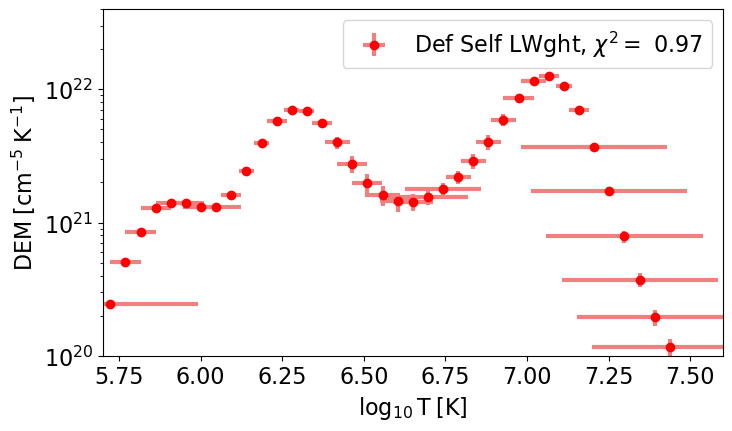

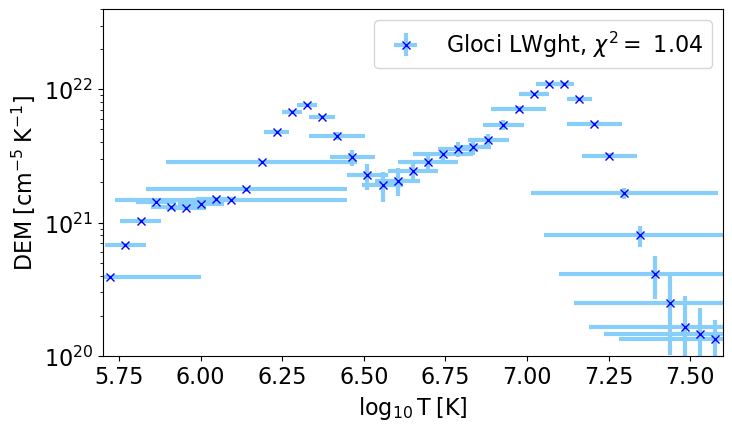

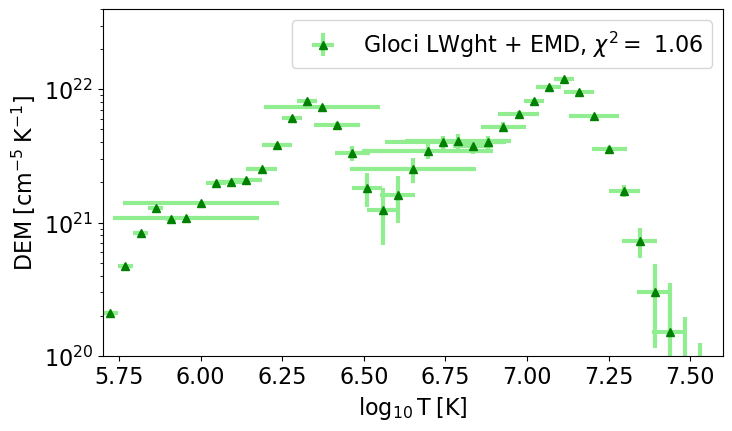

In [35]:
# Now work out the DEM - try 2 of 3 standard ways of running
# 1. Default - reg runs twice, 1st time to work out weight for constraint matrix, then regs with that
#         Best option if don't know what doing, hence its the default 
#         Probably best option of AIA data as well.
dem0,edem0,elogt0,chisq0,dn_reg0=dn2dem(dn_in,edn_in,trmatrix,tresp_logt,temps) #gloci=0 is default behaviour
# 2. EMloci - reg runs once, works out weight for constraint matrix as min of EM Loci, then regs with that
#        If some of your filters have a sharper T response (lines or X-ray obs) might be useful to try
dem1,edem1,elogt1,chisq1,dn_reg1=dn2dem(dn_in,edn_in,trmatrix,tresp_logt,temps,gloci=1)
# 3. EMloci - reg runs once, works out weight for constraint matrix as min of EM Loci, then regs with that
#        If some of your filters have a sharper T response (lines or X-ray obs) might be useful to try
#        Also does the calculation internally in EMD not DEM space, but returns DEM (as default emd_ret=False)
dem2,edem2,elogt2,chisq2,dn_reg2=dn2dem(dn_in,edn_in,trmatrix,tresp_logt,temps,gloci=1,emd_int=True)

#  Plot it all
fig = plt.figure(figsize=(8, 4.5))
plt.errorbar(mlogt,dem0,xerr=elogt0,yerr=edem0,fmt='or',ecolor='lightcoral', \
             elinewidth=3, capsize=0,label='Def Self LWght, $\chi^2 =$ {:0.2f}'.format(chisq0))
plt.xlabel('$\mathrm{\log_{10}T\;[K]}$')
plt.ylabel('$\mathrm{DEM\;[cm^{-5}\;K^{-1}]}$')
plt.ylim([1e20,4e22])
plt.xlim([5.7,7.6])
plt.rcParams.update({'font.size': 16})
plt.yscale('log')
plt.legend()
plt.savefig(save_dir+'demregpy_aiapxl_slw.png',bbox_inches='tight')
plt.show()

#  Plot it all
fig = plt.figure(figsize=(8, 4.5))
plt.errorbar(mlogt,dem1,xerr=elogt1,yerr=edem1,fmt='xb', ecolor='lightskyblue', \
             elinewidth=3, capsize=0,label='Gloci LWght, $\chi^2 =$ {:0.2f}'.format(chisq1))
plt.xlabel('$\mathrm{\log_{10}T\;[K]}$')
plt.ylabel('$\mathrm{DEM\;[cm^{-5}\;K^{-1}]}$')
plt.ylim([1e20,4e22])
plt.xlim([5.7,7.6])
plt.rcParams.update({'font.size': 16})
plt.yscale('log')
plt.legend()
plt.savefig(save_dir+'demregpy_aiapxl_glw.png',bbox_inches='tight')
plt.show()

#  Plot it all
fig = plt.figure(figsize=(8, 4.5))
plt.errorbar(mlogt,dem2,xerr=elogt2,yerr=edem2,fmt='^g',ecolor='lightgreen', \
             elinewidth=3, capsize=0,label='Gloci LWght + EMD, $\chi^2 =$ {:0.2f}'.format(chisq2))
plt.xlabel('$\mathrm{\log_{10}T\;[K]}$')
plt.ylabel('$\mathrm{DEM\;[cm^{-5}\;K^{-1}]}$')
plt.ylim([1e20,4e22])
plt.xlim([5.7,7.6])
plt.rcParams.update({'font.size': 16})
plt.yscale('log')
plt.legend()
# save_path = os.path.join(save_dir, 'dem_feature_1pixel_selection.png')
plt.savefig(save_dir+'demregpy_aiapxl_glw_emd.png',bbox_inches='tight')
plt.show()

Def Self, chisq:  0.9727542628868692
Gloci, chisq:  1.0384353427509259
Gloci+EMD, chisq:  1.0595086459668368
Def Self:  [0.90009116 0.97850125 0.99659509 0.99870841 0.99515319 0.92229747]
Gloci:  [0.90004372 0.95629351 0.99678837 1.00194193 0.98484497 0.99108789]
Gloci+EMD:  [0.89292416 0.96344995 0.98545401 1.00202243 0.98230149 1.01567251]


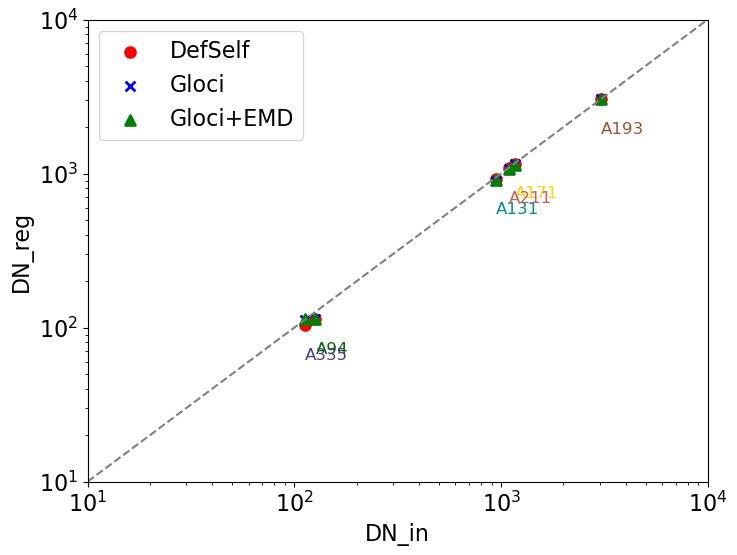

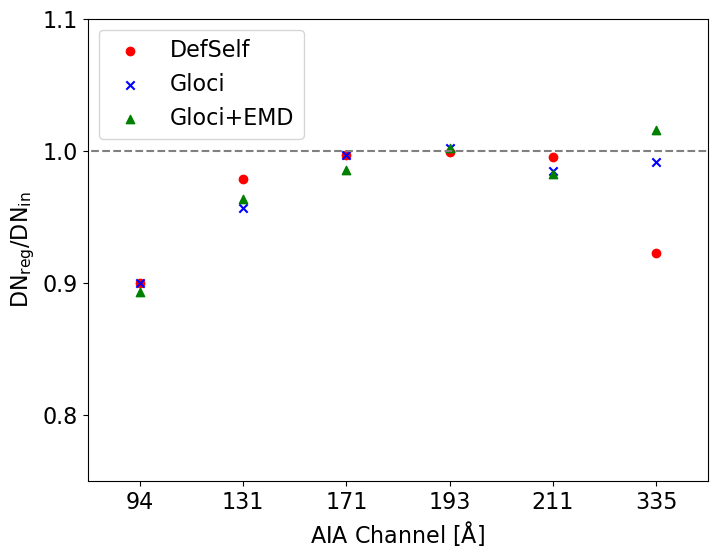

In [36]:
#  How well did they actually do?
print('Def Self, chisq: ',chisq0) # Not bad....
print('Gloci, chisq: ',chisq1) # Worse but expected as just working with AIA filters here
print('Gloci+EMD, chisq: ',chisq2) # Worse but expected as just working with AIA filters here

print('Def Self: ',dn_reg0/dn_in)
print('Gloci: ',dn_reg1/dn_in)
print('Gloci+EMD: ',dn_reg2/dn_in)

clrs=['darkgreen','darkcyan','gold','sienna','indianred','darkslateblue']
fig,ax = plt.subplots(figsize=(8, 6))
plt.scatter(dn_in,dn_reg0,color='red',marker='o',s=50,lw=2,label='DefSelf')
plt.scatter(dn_in,dn_reg1,color='blue',marker='x',s=50,lw=2,label='Gloci')
plt.scatter(dn_in,dn_reg2,color='green',marker='^',s=50,lw=2,label='Gloci+EMD')
for i, lab in enumerate(trin['channels']):
    ax.annotate(lab.decode("utf-8"), (dn_in[i], 0.6*dn_reg0[i]),color=clrs[i],fontsize=12)
plt.xlabel('DN_in')
plt.ylabel('DN_reg')
xyrang=[1e1,1e4]
plt.plot(xyrang,xyrang,color='grey',ls='dashed')
plt.ylim(xyrang)
plt.xlim(xyrang)
plt.rcParams.update({'font.size': 16})
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()
fig.savefig(save_dir+'demregpy_aiapxl_Dreg_Din.png', bbox_inches='tight')


fig,ax = plt.subplots(figsize=(8, 6))
plt.scatter(np.arange(6),dn_reg0/dn_in,marker='o',color='red',label='DefSelf')
plt.scatter(np.arange(6),dn_reg1/dn_in,marker='x',color='blue',label='Gloci')
plt.scatter(np.arange(6),dn_reg2/dn_in,marker='^',color='green',label='Gloci+EMD')
plt.plot([-1,12],[1,1],'--',color='grey')
plt.ylim([0.75,1.1])
plt.xlim([-0.5,5.5])
chlab=[]
for cc in channels:
    chlab.append(int(cc.value))
plt.xticks(np.arange(6),chlab)
plt.xlabel('AIA Channel [$\mathrm{\AA}$]')
plt.ylabel('DN$_\mathrm{reg}$/DN$_\mathrm{in}$')
plt.locator_params(axis='y', nbins=5)
plt.legend()
plt.show()
fig.savefig(save_dir+'demregpy_aiapxl_Dreg_Din_channel.png', bbox_inches='tight')



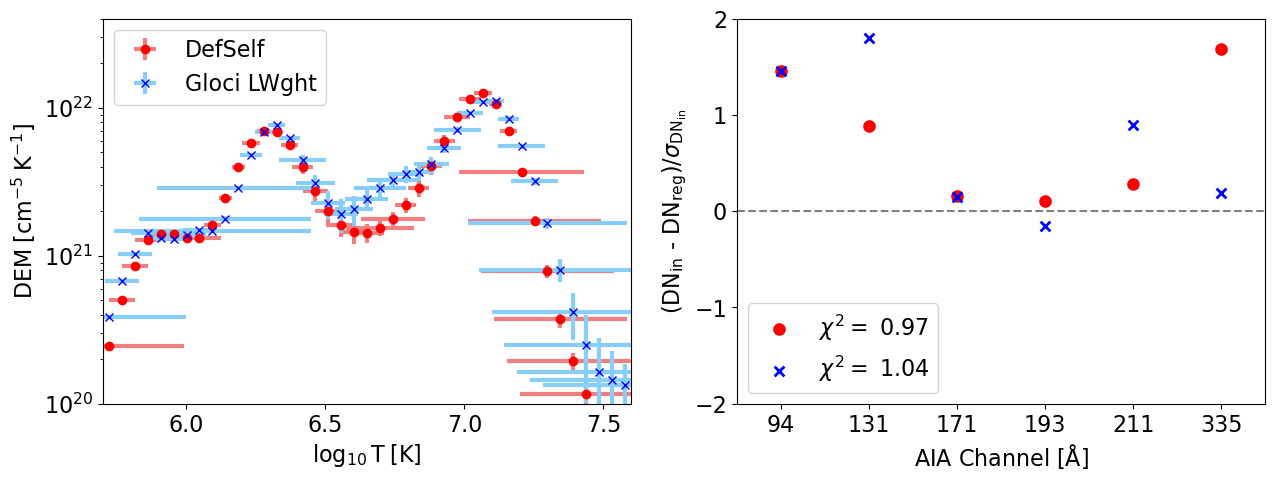

In [37]:
#  Final summary plot for the default run
fig= plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 16})

ax1 = fig.add_subplot(1, 2, 1)
plt.errorbar(mlogt,dem0,xerr=elogt0,yerr=edem0,fmt='or',\
             ecolor='lightcoral', elinewidth=3, capsize=0,label='DefSelf')
plt.errorbar(mlogt,dem1,xerr=elogt1,yerr=edem1,fmt='xb', \
             ecolor='lightskyblue', elinewidth=3, capsize=0,label='Gloci LWght')
plt.xlabel('$\mathrm{\log_{10}T\;[K]}$')
plt.ylabel('$\mathrm{DEM\;[cm^{-5}\;K^{-1}]}$')
plt.ylim([1e20,4e22])
plt.xlim([5.7,7.6])
plt.legend()
plt.yscale('log')

ax2 = fig.add_subplot(1, 2, 2)
plt.scatter(np.arange(6),(dn_in-dn_reg0)/edn_in,marker='o',color='red',\
            s=50,lw=2,label='$\chi^2 =$ {:0.2f}'.format(chisq0))
plt.scatter(np.arange(6),(dn_in-dn_reg1)/edn_in,marker='x',color='blue',\
            s=50,lw=2,label='$\chi^2 =$ {:0.2f}'.format(chisq1))
plt.plot([-1,12],[0,0],'--',color='grey')
plt.ylim([-2,2])
plt.xlim([-0.5,5.5])
chlab=[]
for cc in channels:
    chlab.append(int(cc.value))
plt.xticks(np.arange(6),chlab)
plt.xlabel('AIA Channel [$\mathrm{\AA}$]')
plt.ylabel('(DN$_\mathrm{in}$ - DN$_\mathrm{reg}$)/$\sigma_\mathrm{DN_{in}}$')
plt.locator_params(axis='y', nbins=5)
plt.legend()
plt.show()
fig.savefig(save_dir+'demregpy_aiapxl_DEM_chisq.png', bbox_inches='tight')